<a href="https://www.kaggle.com/code/lalit7881/tamil-nadu-elections-2026-eda-98?scriptVersionId=316979513" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nuhmanpk/tamil-nadu-assembly-election-results-2026/eci_results_tamilnadu_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nuhmanpk/tamil-nadu-assembly-election-results-2026/eci_results_tamilnadu_2026.csv")

In [3]:
df.head()

,Code,Constituency,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% Votes,Round,Last Updated Time,Last Updated Date
0,S221,GUMMIDIPOONDI - 1,T.J.GOVINDARAJAN,Dravida Munnetra Kazhagam,61922,570,62492,26.88,26/26,11:27 PM,04/05/2026
1,S221,GUMMIDIPOONDI - 1,SUDHAKAR.V,All India Anna Dravida Munnetra Kazhagam,65894,481,66375,28.55,26/26,11:27 PM,04/05/2026
2,S221,GUMMIDIPOONDI - 1,M.JAGADEESAN,Bahujan Samaj Party,695,2,697,0.30,26/26,11:27 PM,04/05/2026
3,S221,GUMMIDIPOONDI - 1,"R.SRIDAR. B.L.,",Naam Tamilar Katchi,4707,49,4756,2.05,26/26,11:27 PM,04/05/2026
4,S221,GUMMIDIPOONDI - 1,SDK SANKAR,Aanaithinthiya Jananayaka Pathukappu Kazhagam,593,6,599,0.26,26/26,11:27 PM,04/05/2026


In [4]:
df.tail()

,Code,Constituency,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% Votes,Round,Last Updated Time,Last Updated Date
4252,S22234,KILLIYOOR - 234,AJAI (ALIAS) NAGARAJAN,Independent,240,1,241,0.14,23/23,11:30 PM,04/05/2026
4253,S22234,KILLIYOOR - 234,BERRILA. L,Independent,193,4,197,0.11,23/23,11:30 PM,04/05/2026
4254,S22234,KILLIYOOR - 234,BABY RAJ. P,Independent,157,5,162,0.09,23/23,11:30 PM,04/05/2026
4255,S22234,KILLIYOOR - 234,JUSTIN. M,Independent,188,1,189,0.11,23/23,11:30 PM,04/05/2026
4256,S22234,KILLIYOOR - 234,NOTA,None of the Above,491,11,502,0.28,23/23,11:30 PM,04/05/2026


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Code               4257 non-null   object 
 1   Constituency       4257 non-null   object 
 2   Candidate          4257 non-null   object 
 3   Party              4257 non-null   object 
 4   EVM Votes          4257 non-null   int64  
 5   Postal Votes       4257 non-null   int64  
 6   Total Votes        4257 non-null   int64  
 7   % Votes            4257 non-null   float64
 8   Round              4257 non-null   object 
 9   Last Updated Time  4257 non-null   object 
 10  Last Updated Date  4257 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 366.0+ KB


In [6]:
df.describe()

,EVM Votes,Postal Votes,Total Votes,% Votes
count,4257.000000,4257.000000,4257.000000,4257.000000
mean,11463.899930,122.598778,11586.498708,5.496855
std,25535.983956,283.467189,25786.727983,11.918995
min,2.000000,0.000000,2.000000,0.000000
25%,121.000000,1.000000,122.000000,0.060000
50%,269.000000,2.000000,271.000000,0.130000
75%,1021.000000,21.000000,1031.000000,0.490000
max,219807.000000,2399.000000,220382.000000,58.890000


In [7]:
df.isnull().sum()

Code                 0
Constituency         0
Candidate            0
Party                0
EVM Votes            0
Postal Votes         0
Total Votes          0
% Votes              0
Round                0
Last Updated Time    0
Last Updated Date    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Code', 'Constituency', 'Candidate', 'Party', 'EVM Votes',
       'Postal Votes', 'Total Votes', '% Votes', 'Round', 'Last Updated Time',
       'Last Updated Date'],
      dtype='object')

In [10]:
df.dtypes

Code                  object
Constituency          object
Candidate             object
Party                 object
EVM Votes              int64
Postal Votes           int64
Total Votes            int64
% Votes              float64
Round                 object
Last Updated Time     object
Last Updated Date     object
dtype: object

In [11]:
df.shape

(4257, 11)

In [12]:
df.nunique()

Code                  234
Constituency          234
Candidate            3872
Party                 105
EVM Votes            1796
Postal Votes          692
Total Votes          1788
% Votes               908
Round                  24
Last Updated Time       2
Last Updated Date       1
dtype: int64

## EDA

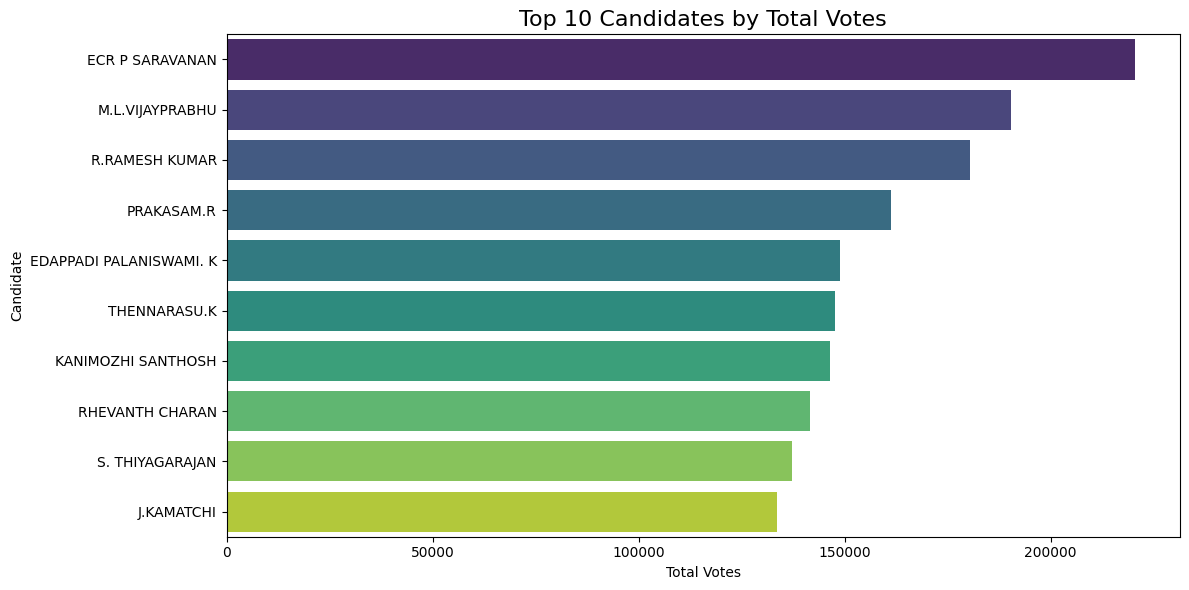

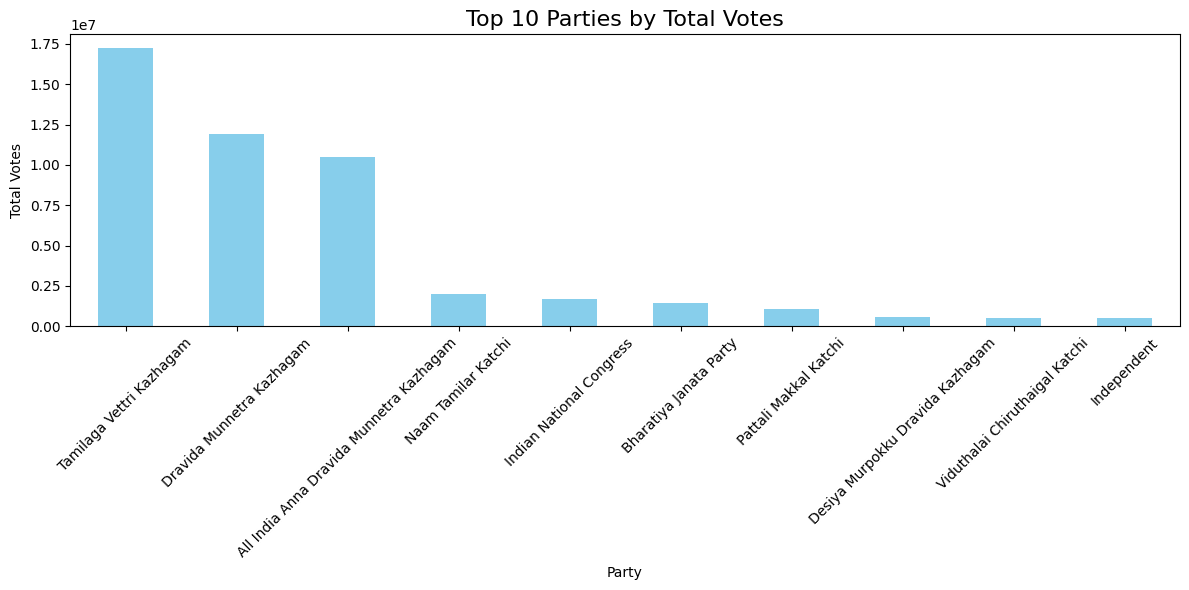

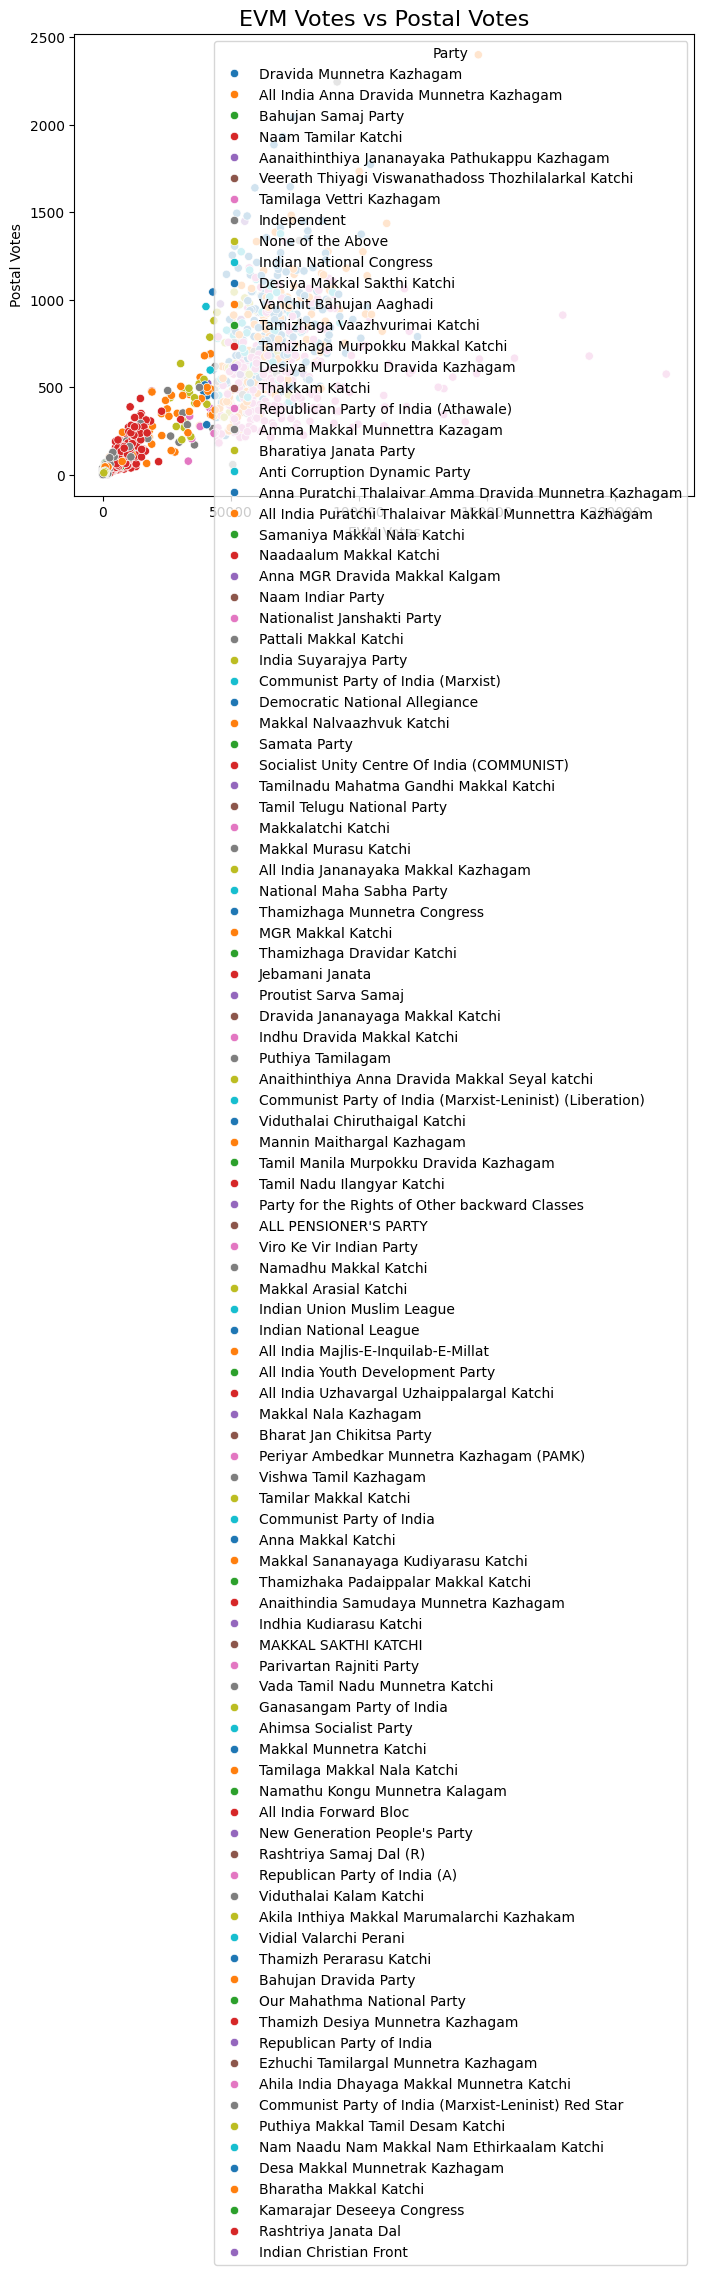

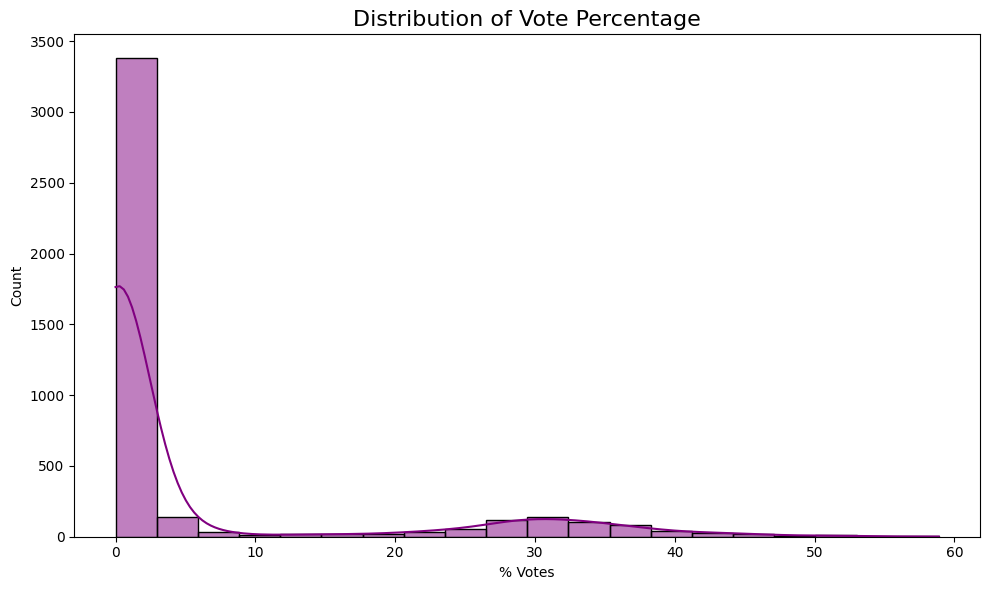

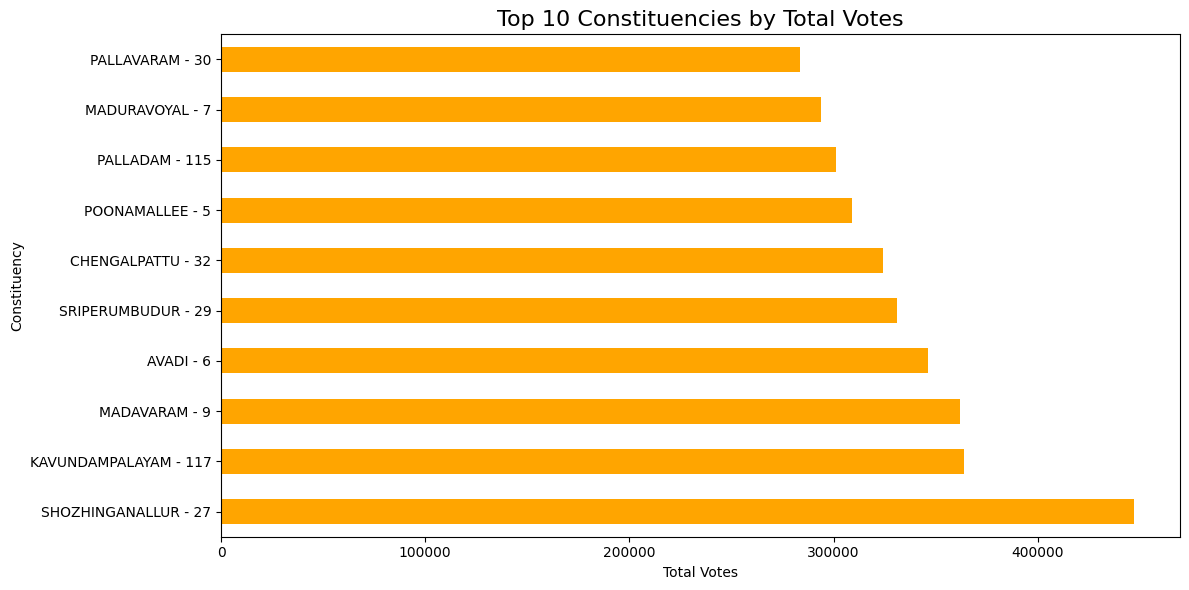

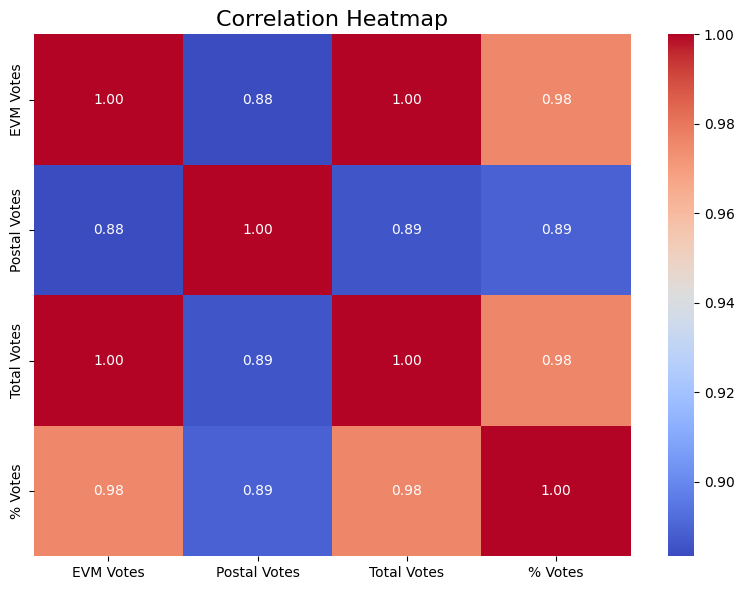

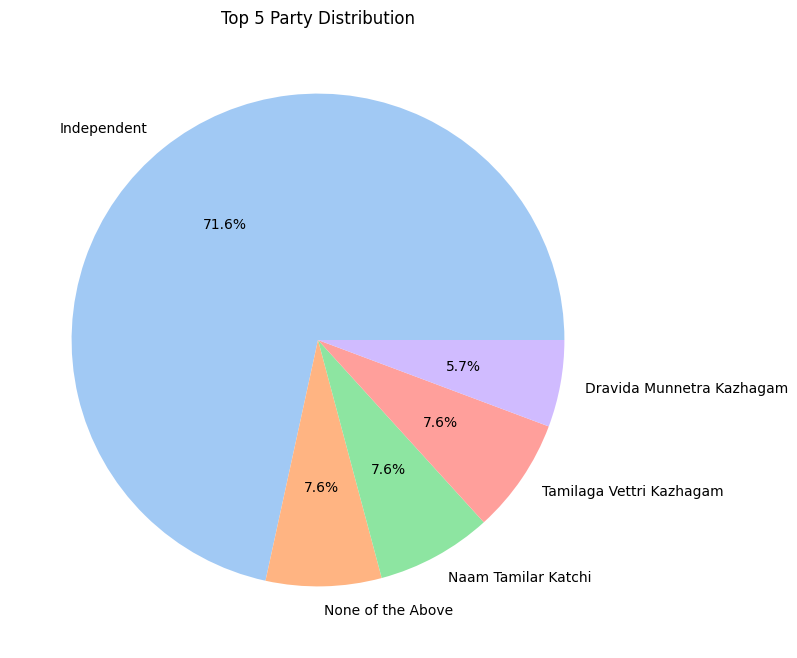

In [13]:
# Convert numeric columns if needed
df['EVM Votes'] = pd.to_numeric(df['EVM Votes'], errors='coerce')
df['Postal Votes'] = pd.to_numeric(df['Postal Votes'], errors='coerce')
df['Total Votes'] = pd.to_numeric(df['Total Votes'], errors='coerce')
df['% Votes'] = pd.to_numeric(df['% Votes'], errors='coerce')

# ==============================
# 1. Top 10 Candidates by Total Votes (Bar Plot)
# ==============================
top_candidates = df.sort_values(by='Total Votes', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_candidates, x='Total Votes', y='Candidate', palette='viridis')
plt.title('Top 10 Candidates by Total Votes', fontsize=16)
plt.xlabel('Total Votes')
plt.ylabel('Candidate')
plt.tight_layout()
plt.show()

# ==============================
# 2. Party-wise Total Votes (Bar Plot)
# ==============================
party_votes = df.groupby('Party')['Total Votes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
party_votes.plot(kind='bar', color='skyblue')
plt.title('Top 10 Parties by Total Votes', fontsize=16)
plt.xlabel('Party')
plt.ylabel('Total Votes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 3. EVM vs Postal Votes (Scatter Plot)
# ==============================
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='EVM Votes', y='Postal Votes', hue='Party', palette='tab10')
plt.title('EVM Votes vs Postal Votes', fontsize=16)
plt.tight_layout()
plt.show()

# ==============================
# 4. Vote Percentage Distribution (Histogram)
# ==============================
plt.figure(figsize=(10,6))
sns.histplot(df['% Votes'], bins=20, kde=True, color='purple')
plt.title('Distribution of Vote Percentage', fontsize=16)
plt.xlabel('% Votes')
plt.tight_layout()
plt.show()

# ==============================
# 5. Constituency-wise Total Votes (Top 10)
# ==============================
const_votes = df.groupby('Constituency')['Total Votes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
const_votes.plot(kind='barh', color='orange')
plt.title('Top 10 Constituencies by Total Votes', fontsize=16)
plt.xlabel('Total Votes')
plt.ylabel('Constituency')
plt.tight_layout()
plt.show()

# ==============================
# 6. Correlation Heatmap
# ==============================
plt.figure(figsize=(8,6))
corr = df[['EVM Votes', 'Postal Votes', 'Total Votes', '% Votes']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# ==============================
# 7. Party Distribution (Pie Chart - Top 5)
# ==============================
top_parties = df['Party'].value_counts().head(5)

plt.figure(figsize=(8,8))
top_parties.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Top 5 Party Distribution')
plt.ylabel('')
plt.show()

## Feature engineering


========== Logistic Regression ==========

Accuracy: 0.9789

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       805
           1       0.82      0.79      0.80        47

    accuracy                           0.98       852
   macro avg       0.90      0.89      0.90       852
weighted avg       0.98      0.98      0.98       852



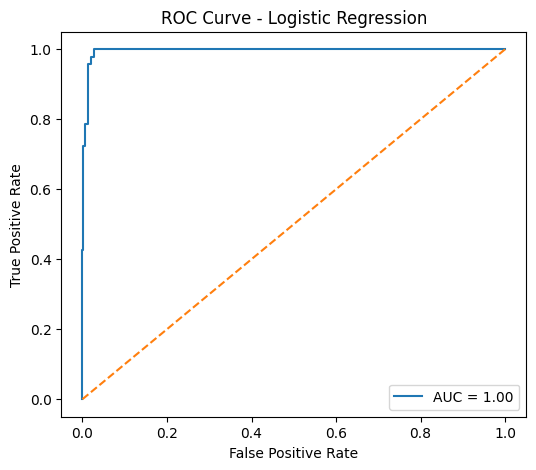


========== Random Forest ==========

Accuracy: 0.9777

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       805
           1       0.80      0.79      0.80        47

    accuracy                           0.98       852
   macro avg       0.90      0.89      0.89       852
weighted avg       0.98      0.98      0.98       852



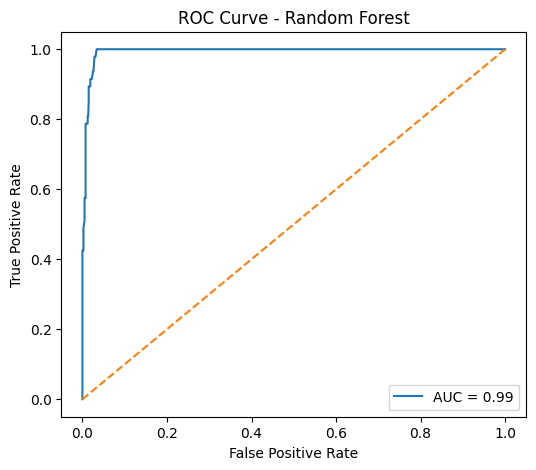

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc


# Convert numeric columns
num_cols = ['EVM Votes', 'Postal Votes', 'Total Votes', '% Votes']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing
df = df.dropna()

# ==============================
# 2. Create TARGET (Winner = 1, else 0)
# ==============================
# Winner = candidate with max votes in each constituency
df['Winner'] = df.groupby('Constituency')['Total Votes'].transform(lambda x: (x == x.max()).astype(int))

# ==============================
# 3. Features & Target
# ==============================
X = df[['Party', 'EVM Votes', 'Postal Votes', '% Votes']]
y = df['Winner']

# ==============================
# 4. Train-Test Split (NO LEAKAGE)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 5. Preprocessing Pipeline
# ==============================
cat_cols = ['Party']
num_cols = ['EVM Votes', 'Postal Votes', '% Votes']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# ==============================
# 6. Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ==============================
# 7. Train + Evaluate
# ==============================
for name, model in models.items():
    print(f"\n========== {name} ==========\n")

    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    # Train ONLY on training data
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}\n")

    # Classification report
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # ==============================
    # 8. ROC Curve
    # ==============================
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend()
    plt.show()

## Thank you...pls upvote!!!!!!!!!